# ACCERT AP1000 to IAT China to CRF

This notebook runs the three-tool workflow:

1. Run the ACCERT AP1000 model and generate account CSV files.
2. Convert the ACCERT account output into a CRF/IAT baseline, then run IAT for China.
3. Use the China-adjusted CSV as the CRF baseline to evaluate FOAK-to-NOAK results.

The AP1000 CRF base case uses a well-executed FOAK construction duration of 76 months.

Source note: the AP1000 and LPSR direct-cost basis used in this workflow follows:

[1]Spangler, Ryan, et al. "Potential Cost Reduction in New Nuclear Deployments Based on Recent AP1000 Experience." , Jun. 2025. https://doi.org/10.2172/2571083
[2]Stewart W.R. and Shirvan K., "Capital cost estimation for advanced nuclear power plants," *Renewable and Sustainable Energy Reviews*, Nov. 2021, 111880, https://doi.org/10.1016/j.rser.2021.111880


In [1]:
from pathlib import Path
import os
import shutil
import subprocess
import sys
import tempfile

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src" / "Main.py").exists():
    REPO_ROOT = Path.cwd().parents[1]

SRC_PATH = REPO_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from crf import accert_output_to_crf_baseline, run_one_scenario, results_to_dataframe, print_scenario_result, save_dashboard, waterfall_to_dataframe
from crf.io.excel_inputs import InputStore
from iat import level_account_summary, run_adjustment

OUTPUT_DIR = Path(os.environ.get(
    "ACCERT_WORKFLOW_OUTPUT_DIR",
    REPO_ROOT / "tutorial" / "combined" / "outputs" / "ap1000_china_notebook",
))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ACCERT_INPUT = REPO_ROOT / "tutorial" / "accert" / "AP1000.son"
REACTOR_TYPE = "AP1000"
COUNTRY = "China"
YEAR_DOLLAR = 2024
CONSTRUCTION_DURATION_MONTHS = 76

ACCERT_INPUT, OUTPUT_DIR

(PosixPath('/Users/jia.zhou/projects/ACCERT/tutorial/accert/AP1000.son'),
 PosixPath('/Users/jia.zhou/projects/ACCERT/tutorial/combined/outputs/ap1000_china_notebook'))

## 1. Run ACCERT AP1000

The ACCERT run uses a temporary SQLite database copy so the reference database in `src/accertdb.sqlite` is not modified.

In [2]:
with tempfile.TemporaryDirectory() as tmp:
    db_path = Path(tmp) / "accertdb.sqlite"
    shutil.copy2(REPO_ROOT / "src" / "accertdb.sqlite", db_path)
    env = {**os.environ, "ACCERT_SQLITE_DB": str(db_path)}
    subprocess.run(
        [sys.executable, str(REPO_ROOT / "src" / "Main.py"), "-i", str(ACCERT_INPUT)],
        cwd=OUTPUT_DIR,
        env=env,
        check=True,
    )

accert_account_csv = sorted(OUTPUT_DIR.glob("ap1000_upd_acc_*.csv"))[-1]
accert_cost_element_csv = sorted(OUTPUT_DIR.glob("ap1000_upd_ce_*.csv"))[-1]
accert_post_csv = sorted(OUTPUT_DIR.glob("ap1000_post_*.csv"))[-1]

print("ACCERT account CSV:", accert_account_csv)
print("ACCERT cost element CSV:", accert_cost_element_csv)
print("ACCERT post-process CSV:", accert_post_csv)

pd.read_csv(accert_account_csv).head(10)

ACCERT account CSV: /Users/jia.zhou/projects/ACCERT/tutorial/combined/outputs/ap1000_china_notebook/ap1000_upd_acc_20260519_002909.csv
ACCERT cost element CSV: /Users/jia.zhou/projects/ACCERT/tutorial/combined/outputs/ap1000_china_notebook/ap1000_upd_ce_20260519_002909.csv
ACCERT post-process CSV: /Users/jia.zhou/projects/ACCERT/tutorial/combined/outputs/ap1000_china_notebook/ap1000_post_20260519_002909.csv


,code_of_account,account_description,total_cost,level,review_status,total_cost_2024
0,2,Total Direct Cost,6.673724e+09,0,Updated,8.336979e+09
1,21,Structures and Improvements,1.873208e+09,1,Updated,2.340057e+09
2,211,Yardwork,1.687825e+08,2,Updated,2.108472e+08
3,211.1,General Yardwork,2.089185e+07,3,Unchanged,2.609861e+07
4,211.4,Railroads,2.477928e+07,3,Unchanged,3.095488e+07
5,211.7,Structure Associated Yardwork,1.231114e+08,3,Updated,1.537937e+08
6,212,Reactor Containment Building,1.230414e+09,2,Updated,1.537064e+09
7,212.1,Building Structure,1.142969e+09,3,Updated,1.427825e+09
8,212.2,Building Services,3.645450e+07,3,Updated,4.553985e+07
9,212.3,Passive cooling pool,5.099098e+07,3,Unchanged,6.369917e+07


## 2. Convert ACCERT Output and Run IAT for China

The converter maps ACCERT AP1000 accounts into the CRF/IAT account layout, keeps the ACCERT direct-account cost basis, and distributes the user-assigned total 20s labor hours using AP1000 baseline labor-hour proportions.

In [3]:
ap1000_baseline, _ = InputStore().get_baseline(REACTOR_TYPE)
total_20s_labor_hours = float(
    ap1000_baseline.loc[
        ap1000_baseline["Account"].astype(str).isin(["21", "22", "23", "24", "26"]),
        "Site Labor Hours",
    ].sum()
)

converted_baseline_csv = OUTPUT_DIR / "ap1000_accert_for_iat_crf.csv"
converted_baseline = accert_output_to_crf_baseline(
    accert_account_csv,
    converted_baseline_csv,
    reactor_type=REACTOR_TYPE,
    total_20s_labor_hours=total_20s_labor_hours,
)

print(f"Assigned total 20s labor hours: {total_20s_labor_hours:,.2f}")
print("Converted CRF/IAT baseline CSV:", converted_baseline_csv)
converted_baseline.head(15)

Assigned total 20s labor hours: 28,902,455.46
Converted CRF/IAT baseline CSV: /Users/jia.zhou/projects/ACCERT/tutorial/combined/outputs/ap1000_china_notebook/ap1000_accert_for_iat_crf.csv


,Account,Title,Total Cost (USD),Factory Equipment Cost,Site Labor Hours,Site Labor Cost,Site Material Cost
0,11,Land & Land Rights,2.661073e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,12,Site Permits,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,13,Plant Licensing,1.909501e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
3,14,Plant Permits,2.058822e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4,15,Plant Studies,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
5,16,Plant Reports,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
6,18,Other Pre-Construction Costs,6.431742e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
7,21,Structures & Improvements,1.873208e+09,3.140387e+08,1.244309e+07,1.066480e+09,4.926890e+08
8,211,Site Preparation/Yard Work,1.687825e+08,1.229953e+06,1.335573e+06,1.047723e+08,6.278024e+07
9,212,Reactor Containment Building,1.230414e+09,2.653541e+08,8.215502e+06,6.998343e+08,2.652260e+08


In [4]:
iat_china_csv = OUTPUT_DIR / "ap1000_accert_china_iat.csv"
iat_result = run_adjustment(
    {
        "reactor_type": "ACCERT output-LR",
        "country": COUNTRY,
        "year_dollar": YEAR_DOLLAR,
        "input_csv": converted_baseline_csv,
        "output_csv": iat_china_csv,
    }
)

print("China-adjusted IAT CSV:", iat_china_csv)
print(f"Input OCC: {iat_result['input_occ']:,.2f}")
print(f"Adjusted OCC: {iat_result['adjusted_occ']:,.2f}")
print(f"Adjustment ratio of OCC: {iat_result['occ_adjustment_ratio']:.4f}")

level_account_summary(iat_result["adjusted_costs"], max_level=2)

China-adjusted IAT CSV: /Users/jia.zhou/projects/ACCERT/tutorial/combined/outputs/ap1000_china_notebook/ap1000_accert_china_iat.csv
Input OCC: 14,015,836,005.53
Adjusted OCC: 9,952,955,444.02
Adjustment ratio of OCC: 0.7101


,COA,Level,Title,Original Total Cost,Adjusted Total Cost,Difference,Adjustment Ratio
0,10,1,Capitalized Pre-Construction Costs,2.785168e+08,2.290786e+08,-4.943816e+07,0.822495
1,20,1,Capitalized Direct Costs,6.673724e+09,4.824292e+09,-1.849431e+09,0.722879
2,30,1,Capitalized Indirect Services Costs,6.921703e+09,4.763508e+09,-2.158196e+09,0.688199
3,50,1,Capitalized Supplementary Costs,1.418922e+08,1.360766e+08,-5.815550e+06,0.959014
4,60,1,Capitalized Financial Costs,7.519444e+09,7.519444e+09,0.000000e+00,1.000000
5,11,2,Land & Land Rights,2.661073e+06,2.661073e+06,0.000000e+00,1.000000
6,12,2,Site Permits,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
7,13,2,Plant Licensing,1.909501e+08,1.499531e+08,-4.099699e+07,0.785300
8,14,2,Plant Permits,2.058822e+07,1.214705e+07,-8.441172e+06,0.590000
9,15,2,Plant Studies,0.000000e+00,0.000000e+00,0.000000e+00,0.000000


### IAT Visualization

The chart below compares the ACCERT-derived AP1000 baseline against the China-adjusted IAT baseline by top-level COA group.

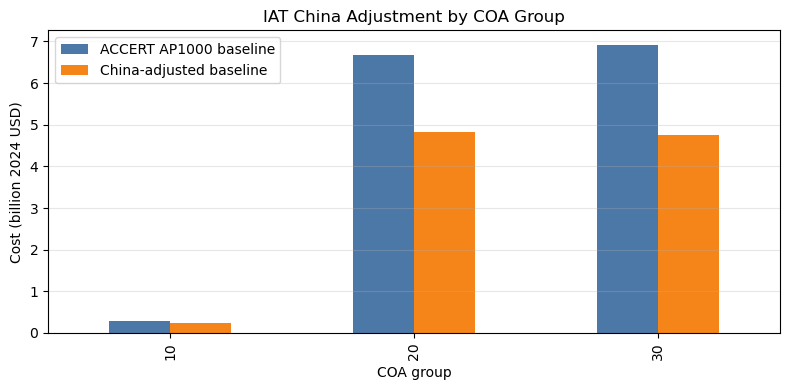

In [5]:
iat_summary = level_account_summary(iat_result["adjusted_costs"], max_level=1)
plot_df = iat_summary.loc[iat_summary["COA"].isin(["10", "20", "30"])].copy()
plot_df = plot_df.set_index("COA")[["Original Total Cost", "Adjusted Total Cost"]] / 1e9

ax = plot_df.plot(kind="bar", figsize=(8, 4), color=["#4C78A8", "#F58518"])
ax.set_title("IAT China Adjustment by COA Group")
ax.set_ylabel("Cost (billion 2024 USD)")
ax.set_xlabel("COA group")
ax.legend(["ACCERT AP1000 baseline", "China-adjusted baseline"])
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

## 3. Run CRF with the China-Adjusted Baseline

CRF reads the IAT CSV through `baseline_csv`. Because the IAT output includes adjusted cost columns, CRF uses those adjusted columns as the new baseline.

In [6]:
crf_config = {
    "reactor_type": REACTOR_TYPE,
    "baseline_csv": str(iat_china_csv),
    "f_22": 250_000_000,
    "f_2321": 150_000_000,
    "land_cost_per_acre_0": 22_000,
    "construction_duration_0": CONSTRUCTION_DURATION_MONTHS,
    "startup_0": 25,
    "staggering_ratio": 0.75,
}

crf_levers = {
    "num_orders": 10,
    "num_NOAK": 4,
    "itc_percent": 0,
    "n_itc": 0,
    "interest_percent": 3,
    "design_completion_percent": 70,
    "design_maturity": 1,
    "proc_exp": 1,
    "N_proc": 2,
    "ce_exp": 1,
    "N_cons": 3,
    "ae_exp": 1,
    "N_AE": 4,
    "standardization_percent": 80,
    "modularity_code": 0,
    "bop_grade_code": 0,
    "rb_grade_code": 0,
}

crf_result = run_one_scenario(crf_config, crf_levers)
print_scenario_result(crf_result)
results_to_dataframe(crf_result)

Results by plant number:

 Plant_number     OCC     TCI  duration  STAUP   D10s    D20s    D30s  D50s   D60s  D20_equip  D20_mat  D20_labor
            1 7104.56 7743.32     88.19  25.00 102.54 3538.83 3424.13 39.06 638.76    1569.67   314.13    1655.03
            2 3746.02 3977.27     65.06  17.50 102.54 2175.58 1443.88 24.01 231.25    1119.05   201.69     854.84
            3 2946.74 3096.58     58.80  14.20 102.54 1813.47 1010.29 20.43 149.84    1001.65   169.80     642.03
            4 2753.73 2876.85     54.98  12.25 102.54 1739.77  891.85 19.57 123.13     995.01   161.49     583.26
            5 2618.61 2724.06     52.18  10.92 102.54 1686.65  810.46 18.96 105.44     989.91   155.33     541.41
            6 2516.74 2609.33     50.01   9.94 102.54 1645.69  750.00 18.51  92.59     985.77   150.47     509.46
            7 2436.11 2518.84     48.24   9.18 102.54 1612.68  702.75 18.14  82.73     982.28   146.48     483.91
            8 2370.06 2446.81     46.76   8.57 102.54 1585.21 

,Plant number,OCC,Net OCC,TCI,NCI,Construction duration,Startup duration,Preconstruction costs,Direct costs,Direct costs: equipment,Direct costs: material,Direct costs: labor,Indirect costs,Supplementary costs,Financing costs,OCC reduction from FOAK,TCI reduction from FOAK
0,1,7104.562325,NaN,7743.317622,NaN,88.188438,25.000000,102.541916,3538.830616,1569.667247,314.134575,1655.028794,3424.131574,39.058219,638.755297,0.000000,0.000000
1,2,3746.015509,NaN,3977.269899,NaN,65.060414,17.500000,102.541916,2175.583219,1119.053249,201.690397,854.839573,1443.877909,24.012465,231.254390,47.273099,48.636100
2,3,2946.739722,NaN,3096.584353,NaN,58.797767,14.204508,102.541916,1813.472444,1001.647423,169.797416,642.027605,1010.293526,20.431836,149.844631,58.523276,60.009591
3,4,2753.725509,NaN,2876.853528,NaN,54.976346,12.250000,102.541916,1739.769400,995.014501,161.492221,583.262678,891.847030,19.567164,123.128019,61.240040,62.847275
4,5,2618.613943,NaN,2724.056091,NaN,52.184107,10.921161,102.541916,1686.652642,989.910375,155.331000,541.411266,810.457500,18.961885,105.442148,63.141798,64.820556
5,6,2516.744396,NaN,2609.329565,NaN,50.008287,9.943156,102.541916,1645.693402,985.766244,150.471818,509.455340,750.003553,18.505526,92.585169,64.575659,66.302176
6,7,2436.113504,NaN,2518.840360,NaN,48.239588,9.184917,102.541916,1612.676009,982.280731,146.482224,483.913054,702.751267,18.144312,82.726857,65.710576,67.470786
7,8,2370.064468,NaN,2446.806908,NaN,46.758117,8.575000,102.541916,1585.211594,979.274928,143.111884,462.824782,664.462534,17.848423,76.742441,66.640247,68.401052
8,9,2314.559874,NaN,2385.885755,NaN,45.489177,8.070722,102.541916,1561.825172,976.633968,140.203460,444.987744,632.593015,17.599771,71.325881,67.421499,69.187810
9,10,2266.985188,NaN,2333.762357,NaN,44.383280,7.644812,102.541916,1541.546908,974.279734,137.651906,429.615267,605.509720,17.386644,66.777169,68.091135,69.860950


### CRF Visualization

The dashboard and trend plots summarize FOAK-to-NOAK changes using the China-adjusted AP1000 baseline.

CRF dashboard: /Users/jia.zhou/projects/ACCERT/tutorial/combined/outputs/ap1000_china_notebook/ap1000_china_crf_dashboard.png


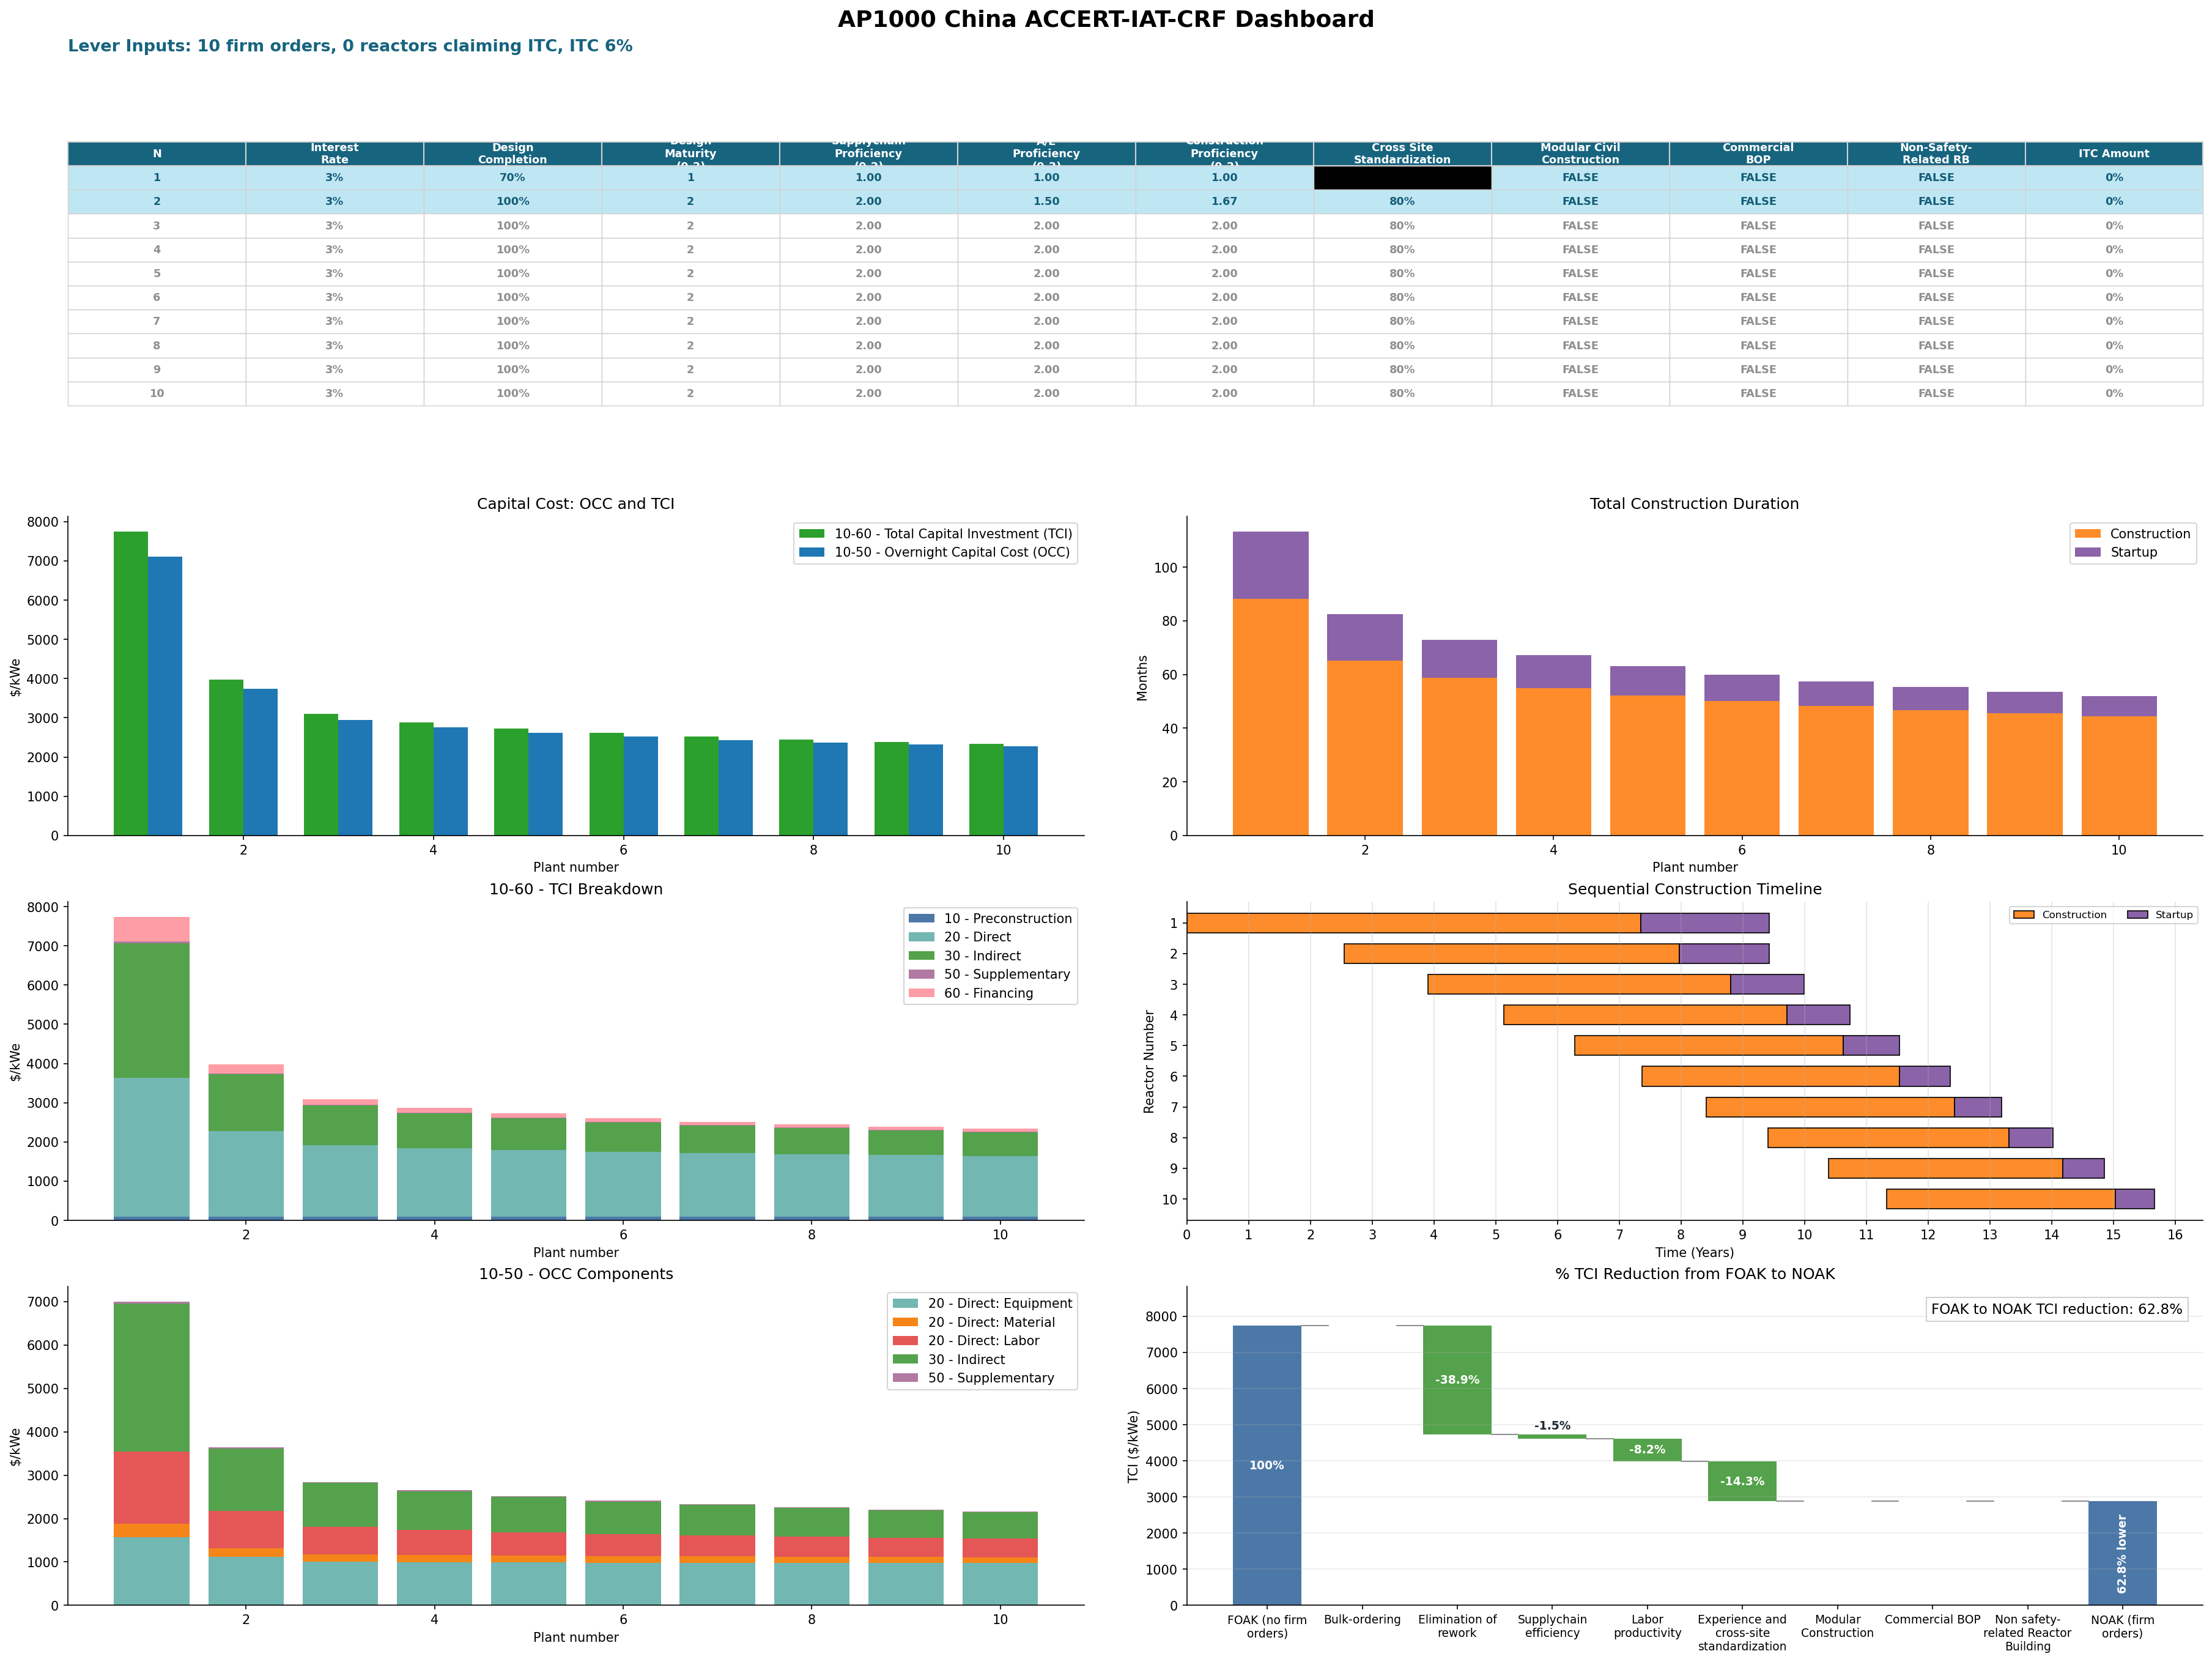

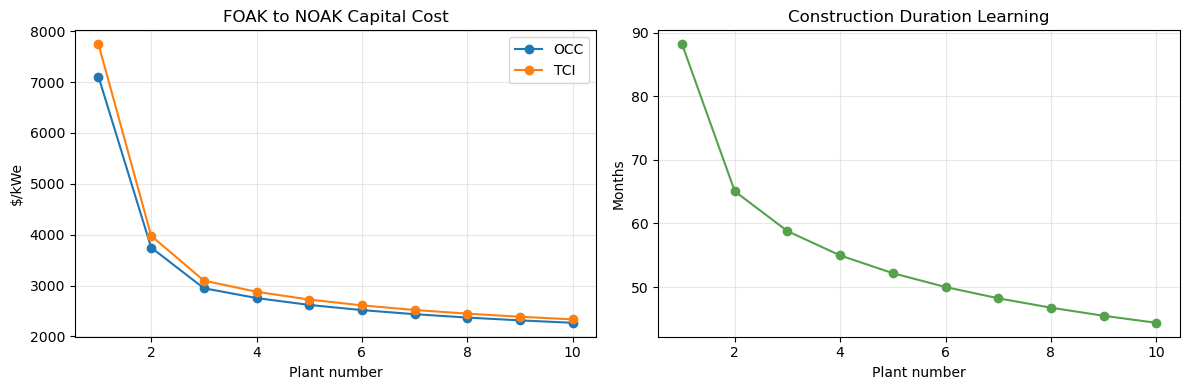

In [7]:
dashboard_path = OUTPUT_DIR / "ap1000_china_crf_dashboard.png"
save_dashboard(
    crf_result,
    dashboard_path,
    title="AP1000 China ACCERT-IAT-CRF Dashboard",
    show_levers=True,
)
print("CRF dashboard:", dashboard_path)
display(Image(filename=str(dashboard_path)))

plants = results_to_dataframe(crf_result)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(plants["Plant number"], plants["OCC"], marker="o", label="OCC")
axes[0].plot(plants["Plant number"], plants["TCI"], marker="o", label="TCI")
axes[0].set_title("FOAK to NOAK Capital Cost")
axes[0].set_xlabel("Plant number")
axes[0].set_ylabel("$/kWe")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(plants["Plant number"], plants["Construction duration"], marker="o", color="#54A24B")
axes[1].set_title("Construction Duration Learning")
axes[1].set_xlabel("Plant number")
axes[1].set_ylabel("Months")
axes[1].grid(alpha=0.3)
plt.tight_layout()

In [8]:
summary = pd.DataFrame(
    [
        {
            "ACCERT account CSV": str(accert_account_csv),
            "IAT China CSV for CRF": str(iat_china_csv),
            "FOAK OCC ($/kWe)": crf_result["OCC_1"],
            "NOAK OCC ($/kWe)": crf_result[f"OCC_{crf_levers['num_NOAK']}"],
            "FOAK TCI ($/kWe)": crf_result["TCI_1"],
            "NOAK TCI ($/kWe)": crf_result[f"TCI_{crf_levers['num_NOAK']}"],
            "FOAK construction duration (months)": crf_result["duration_1"],
            "NOAK construction duration (months)": crf_result[f"duration_{crf_levers['num_NOAK']}"],
        }
    ]
)
summary

,ACCERT account CSV,IAT China CSV for CRF,FOAK OCC ($/kWe),NOAK OCC ($/kWe),FOAK TCI ($/kWe),NOAK TCI ($/kWe),FOAK construction duration (months),NOAK construction duration (months)
0,/Users/jia.zhou/projects/ACCERT/tutorial/combi...,/Users/jia.zhou/projects/ACCERT/tutorial/combi...,7104.562325,2753.725509,7743.317622,2876.853528,88.188438,54.976346
